In [179]:
from cesnet_datazoo.datasets import CESNET_QUIC22
from cesnet_datazoo.config import DatasetConfig, AppSelection, ValidationApproach

# dataset = CESNET_QUIC22("~/datasets/CESNET-QUIC22/", size="XS")

# common_params = {
#     "dataset": dataset,
#     "apps_selection": AppSelection.ALL_KNOWN,
#     "train_period_name": "W-2022-44",
#     "val_approach": ValidationApproach.SPLIT_FROM_TRAIN,
#     "train_val_split_fraction": 0.2,
#     "use_packet_histograms": True,
# }
# dataset_config = DatasetConfig(**common_params)
# dataset.set_dataset_config_and_initialize(dataset_config)
# train_dataframe = dataset.get_train_df(flatten_ppi=True)
# val_dataframe = dataset.get_val_df(flatten_ppi=True)
# test_dataframe = dataset.get_test_df(flatten_ppi=True)

In [180]:
def topx_indexes(dataframe, nclasses):
    grouped_counts = dataframe.groupby("APP").size()
    grouped_counts = grouped_counts.sort_values(ascending=False)

    topx_groups = grouped_counts.head(nclasses).index

    return topx_groups

def QUIC_dataset(nclasses = 0):
    from cesnet_datazoo.datasets import CESNET_QUIC22
    from cesnet_datazoo.config import DatasetConfig, AppSelection, ValidationApproach

    dataset = CESNET_QUIC22("~/datasets/CESNET-QUIC22/", size="XS")

    common_params = {
        "dataset" : dataset,
        "apps_selection" : AppSelection.ALL_KNOWN,
        "test_period_name" : "W-2022-44",
        "val_approach": ValidationApproach.SPLIT_FROM_TRAIN,
        "train_val_split_fraction": 0.2
    }

    dataset_config = DatasetConfig(**common_params)
    dataset.set_dataset_config_and_initialize(dataset_config)
    train_dataframe = dataset.get_train_df(flatten_ppi=True)
    val_dataframe = dataset.get_val_df(flatten_ppi=True)
    test_dataframe = dataset.get_test_df(flatten_ppi=True)

    if nclasses != 0:
        topx_groups = topx_indexes(train_dataframe, nclasses)

        train_dataframe = train_dataframe[train_dataframe["APP"].isin(topx_groups)]
        test_dataframe  = test_dataframe[test_dataframe["APP"].isin(topx_groups)]
        val_dataframe   = val_dataframe[val_dataframe["APP"].isin(topx_groups)]

    return (train_dataframe, val_dataframe, test_dataframe)

(train_dataframe, val_dataframe, test_dataframe) = QUIC_dataset()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/cesnet_datazoo/config.py:341: UserWarning: Some test dates (20221031) are before or equal to the last train date (20221106). This might lead to improper evaluation and should be avoided.
  warnings.warn(f"Some test dates ({min(test_dates).strftime('%Y%m%d')}) are before or equal to the last train date ({max(train_dates).strftime('%Y%m%d')}). This might lead to improper evaluation and should be avoided.")


Loading data from dataloader


100%|██████████| 8162/8162 [00:12<00:00, 677.55it/s] 


Loading data from dataloader


100%|██████████| 192/192 [00:06<00:00, 31.62it/s]


Loading data from dataloader


100%|██████████| 957/957 [00:10<00:00, 92.08it/s] 


In [181]:
import numpy as np

def create_balanced_test_data(nfeatures, test_dataframe, total = 10000):
    grouped = test_dataframe.groupby("APP")
    nclasses = len(grouped)

    nfrom_class = int(total / nclasses)


    X_arr = np.ndarray(shape = (nfrom_class * len(grouped), nfeatures))
    y_arr = np.ndarray(shape = (nfrom_class * len(grouped),))

    for index, i in enumerate(grouped):
        X_temp = i[1].drop(columns="APP").to_numpy()
        y_temp = i[1]["APP"].to_numpy()

        X_arr[index*nfrom_class:(index * nfrom_class) + nfrom_class] = X_temp[:nfrom_class]
        y_arr[index*nfrom_class:(index * nfrom_class) + nfrom_class] = y_temp[:nfrom_class]

    return (X_arr, y_arr)

In [236]:
from pyqlearning.q_learning import QLearning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
from sklearn.neighbors import LocalOutlierFactor, KNeighborsClassifier

from collections import defaultdict
from dataclasses import dataclass, asdict
from math import log
import random

import pandas as pd
from tqdm import tqdm

import time
import faiss

used_features  = [1, 1, 0, 0, 1]
classes_amount = [6, 2, 5, 2, 6]

@dataclass
class State_key:
    predict_proba : int # 6 values [0.15, 0.3, 0.45, 0.6, 0.75]
    hit : int
    lof : int 
    novelty : int 
    faiss : int

    def write(self):
        ret = "State_key("

        for index, field in enumerate(self.__dataclass_fields__):
            if used_features[index]:
                ret += field + "=" + str(getattr(self, field)) + ", "

        ret = ret[:-2] # remove trailing ", "

        ret += ")"

        return ret

    def __hash__(self):
        if hasattr(self, 'hash'):
            return self.hash
        
        value = 0
        multiplier = 1
        for index, field in enumerate(self.__dataclass_fields__):
            if used_features[index]:
                value += getattr(self, field) * multiplier
                multiplier *= classes_amount[index]
        self.hash = value

        return value

    def __eq__(self, other):
        if not isinstance(other, State_key) or self.__hash__() != other.__hash__():
            return False

        return True
        
class Q(QLearning):
    def big_test(self, path = "out.txt"):
        with open(path, "a") as f:
            f.write(str(self.to_i) + "/" + str(self.t + self.base_samples))
            
            clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
            clf.fit(self.X_used[:self.to_i], self.y_used[:self.to_i])
            
            predict_arr = clf.predict(self.X_big_test)
            
            f.write(f"q_learning_f1: {f1_score(self.y_big_test, predict_arr, average='macro'):.4f}" + "\n")

            val = 0
            for _ in range(3):
                clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
                indices = np.random.choice(self.base_samples + self.t, self.to_i, replace=False)
        
                clf.fit(self.X[indices], self.y[indices])
                
                predict_arr = clf.predict(self.X_big_test)

                val += f1_score(self.y_big_test, predict_arr, average='macro')

            val /= 3
            f.write(f"random_learning_f1: {val:.4f}" + "\n")
            
            clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
            clf.fit(self.X_u[:self.u_to_i], self.y_u[:self.u_to_i])

            predict_arr = clf.predict(self.X_big_test)
            
            f.write(f"uncertainty_sampling_f1: {f1_score(self.y_big_test, predict_arr, average='macro'):.4f} ({self.u_to_i} picked)" + "\n")

            clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
            clf.fit(self.X[:self.base_samples + self.t], self.y[:self.base_samples + self.t])
            
            predict_arr = clf.predict(self.X_big_test)
            
            f.write(f"total_learning_f1: {f1_score(self.y_big_test, predict_arr, average='macro'):.4f}" + "\n")
            
            q_df = self.q_df
            q_df = q_df.sort_values(by=["q_value"], ascending=False)
            f.write(str(q_df.head()) + "\n\n")

    def get_lof_prediction(self, index):
        self.X_used[self.to_i] = self.X[index]

        clf = LocalOutlierFactor(n_jobs=-1, n_neighbors=10)
        clf.fit(self.X_used[:self.to_i + 1])

        print(clf.negative_outlier_factor_[-1] * -1)

        return clf.negative_outlier_factor_[-1] * -1
    
    def get_novelty_prediction(self, index):
        clf = LocalOutlierFactor(n_jobs=-1, n_neighbors=100, novelty=True)
        clf.fit(self.X_used[:self.to_i])

        novel = clf.predict(self.X[index].reshape(1, -1))[0]
        if novel == -1:
            novel = 0

        return int(novel)
    
    def get_faiss_novelty(self, index, action_key):
        if action_key:
            self.faiss_index.add(self.X[index-1:index])
            # self.faiss_dict[self.X[index]] = self.y[index]

        _, I = self.faiss_index.search(self.X[index:index+1], 100)

        arr = np.zeros(105)

        for el in I[0]:
            arr[int(self.y_used[el])] += 1

        return np.max(arr) / 100
        
    def get_clf_prediction(self, index):
        next_class = self.y[index]

        proba = np.max(self.clf.predict_proba(self.X[index].reshape(1, -1))[0])
        hit = (self.clf.predict(self.X[index].reshape(1, -1)) == next_class)[0]

        clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
        clf.fit(self.X_u[:self.u_to_i], self.y_u[:self.u_to_i])
        self.last_proba = np.max(clf.predict_proba(self.X[index].reshape(1, -1))[0])

        return (proba, int(hit))

    def value_into_discrete(self, value, thresholds):
        for i, threshold in enumerate(thresholds):
            if value < threshold:
                return i
        return len(thresholds)

    def update_state(self, state_key, action_key):
        self.q_count[(state_key, action_key)] += 1
        sample_index = self.base_i + self.t + 1

        next_class = self.y[sample_index]

        if action_key == 1:
            self.used += 1

        (proba, hit) = self.get_clf_prediction(sample_index)
        proba = self.value_into_discrete(proba, self.PREDICT_PROBA_VALUES)

        # lof = self.get_lof_prediction(sample_index)
        # lof = self.value_into_discrete(lof, self.LOF_VALUES)
        lof = 0

        # novelty = self.get_novelty_prediction(sample_index)
        novelty = 0

        faiss = self.get_faiss_novelty(sample_index, action_key)
        faiss = self.value_into_discrete(faiss, self.FAISS_PROBA_VALUES)

        return State_key(proba, hit, lof, novelty, faiss)

    def initialize(self, cols, iters, already_used, epsilon = 0.9, alpha = 0.2, gamma = 0.9):
        self.q_count = defaultdict(int)

        self.epsilon_greedy_rate = epsilon
        self.alpha_value         = alpha
        self.gamma_value         = gamma

        self.m_depth = 15

        clf = LocalOutlierFactor(n_jobs=-1, n_neighbors=10)
        clf.fit(self.X[:10000])
        arr = clf.negative_outlier_factor_
        arr = arr * -1
        arr = np.sort(arr)

        self.faiss_index = faiss.IndexFlatL2(cols)

        self.LOF_VALUES = np.quantile(arr, np.linspace(0, 1, 5 + 1))[1:-1]
        self.PREDICT_PROBA_VALUES = [0.15, 0.3, 0.45, 0.6, 0.75]
        self.FAISS_PROBA_VALUES = [0.1, 0.2, 0.3, 0.4, 0.5]

        self.func_time = 0 # debug
        self.u_threshold = 0.4
        self.last_proba = 0

        self.used         = already_used
        self.base_samples = already_used
        self.base_i       = already_used - 1
        self.to_i         = already_used
        self.u_to_i       = already_used

        self.X_u    = np.ndarray(shape = (iters + already_used, cols))
        self.y_u    = np.ndarray(shape = (iters + already_used,))
        self.X_used = np.ndarray(shape = (iters + already_used, cols))
        self.y_used = np.ndarray(shape = (iters + already_used,))
        self.last_f1 = 0

        self.X_u[:self.base_samples]    = self.X[:self.base_samples]
        self.y_u[:self.base_samples]    = self.y[:self.base_samples]
        self.X_used[:self.base_samples] = self.X[:self.base_samples]
        self.y_used[:self.base_samples] = self.y[:self.base_samples]

        self.faiss_index.add(self.X[:self.base_samples])

        self.clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
        self.last_f1 = self.test_acc()

        self.vis_values = { "random": [],
                            "uncertainty": [],
                            "qlearning": [] }
    
    def extract_possible_actions(self, state_key):
        return list({0, 1})

    def select_action(self, state_key, next_action_list):
        epsilon_greedy_flag = bool(np.random.binomial(n=1, p=self.epsilon_greedy_rate))

        if epsilon_greedy_flag is False:
            action_key = random.choice(next_action_list)
        else:
            action_key = self.predict_next_action(state_key, next_action_list)

        return action_key

    def train_clf(self, clf):
        clf.fit(self.X_used[:self.to_i], 
                self.y_used[:self.to_i])

    def test_acc(self):
        # clf = KNeighborsClassifier(n_jobs=-1, n_neighbors=100)
        # clf.fit(self.X_used[:self.to_i], self.y_test[:self.to_i])
        # predict_arr = clf.predict(self.X_test)
        # kn_score = f1_score(self.y_test, predict_arr, average="macro")

        runs = 3
        score = 0
        for _ in range(runs):
            self.clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
            self.train_clf(self.clf)
            predict_arr = self.clf.predict(self.X_test)
            score += f1_score(self.y_test, predict_arr, average="macro")

        self.last_f1_rf = score / runs

        # return ((score / runs) + kn_score) / 2
        return score / runs
    
    def observe_reward_value(self, state_key, action_key):
        start = time.time()

        self.X_used[self.to_i] = self.X[self.base_i + self.t]
        self.y_used[self.to_i] = self.y[self.base_i + self.t]

        self.to_i += 1

        cur_f1 = self.test_acc()
        reward = cur_f1 - self.last_f1

        if action_key == 0:
            self.to_i -= 1
            reward = -reward
        else:
            self.last_f1 = cur_f1

        end = time.time()
        self.func_time += end - start

        return reward

    def visualize_learning_result(self, state_key):
        # uncertain
        clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
        clf.fit(self.X_u[:self.u_to_i], self.y_u[:self.u_to_i])
        predict_arr = clf.predict(self.X_test)
        u_f1 = f1_score(self.y_test, predict_arr, average='macro')

        # random
        clf = RandomForestClassifier(max_depth=self.m_depth, n_jobs=-1)
        indices = np.random.choice(self.base_samples + self.t, self.to_i, replace=False)
        clf.fit(self.X[indices], self.y[indices])
        predict_arr = clf.predict(self.X_test)
        r_f1 = f1_score(self.y_test, predict_arr, average='macro')

        self.vis_values["random"].append(r_f1)
        self.vis_values["uncertainty"].append(u_f1)
        self.vis_values["qlearning"].append(self.last_f1_rf)

    def uncertainty(self):
        if self.last_proba < self.u_threshold:
            self.X_u[self.u_to_i] = self.X[self.base_i + self.t]
            self.y_u[self.u_to_i] = self.y[self.base_i + self.t]
            self.u_to_i += 1

    def learn(self, state_key, batch, limit=1000, increased_rd = 1, decrease_alpha = 0):
        start = time.time()

        self.t = 1
        last_t = 1

        for _ in tqdm(range(1, limit + 1)):
            if self.t - last_t > 1000:
                self.big_test()
                last_t = self.t

            self.epsilon_greedy_rate = min(self.t / increased_rd, 0.95)
            self.alpha_value = max(self.alpha_value - decrease_alpha, 0.05)

            next_action_list = self.extract_possible_actions(state_key)
            action_key = self.select_action(
                state_key=state_key,
                next_action_list=next_action_list
            )

            reward_value = self.observe_reward_value(state_key, action_key)
            self.uncertainty()

            # Max-Q-Value in next action time.
            next_state_key = self.update_state(
                state_key=state_key,
                action_key=action_key
            )

            next_next_action_list = self.extract_possible_actions(next_state_key)
            next_action_key = self.predict_next_action(next_state_key, next_next_action_list)
            next_max_q = self.extract_q_df(next_state_key, next_action_key)

            # Update Q-Value.
            self.update_q(
                state_key=state_key,
                action_key=action_key,
                reward_value=reward_value,
                next_max_q=next_max_q
            )
            # Update State.
            state_key = next_state_key

            # Normalize.
            self.normalize_q_value()
            self.normalize_r_value()

            # Vis.
            self.visualize_learning_result(state_key)
            # Check.
            if self.check_the_end_flag(state_key) is True:
                break

            self.t += 1

        print(self.func_time / (time.time() - start))


In [237]:
increased_rd = 500 # increased randomness for n iters
decrease_alpha = 0.00003
iters = 4000
base_samples_amount = 400
epsilon = 0.9
alpha = 0.2
gamma = 0.7
runs = 1
batch = 1

vis_arr = []

for i in range(runs):
    train_dataframe = train_dataframe.sample(frac=1).reset_index(drop=True)
    test_dataframe = test_dataframe.sample(frac=1).reset_index(drop=True)

    q = Q()    

    q.X = train_dataframe.drop(columns="APP").to_numpy()
    q.y = train_dataframe["APP"].to_numpy()

    q.X_big_test = test_dataframe.drop(columns="APP").to_numpy()[:100000]
    q.y_big_test = test_dataframe["APP"].to_numpy()[:100000]

    nfeatures = q.X.shape[1]

    # q.X_test = test_dataframe.drop(columns="APP").to_numpy()[100000:110000]
    # q.y_test = test_dataframe["APP"].to_numpy()[100000:110000]
    (q.X_test, q.y_test) = create_balanced_test_data(nfeatures, test_dataframe, total=10000)

    q.initialize(nfeatures, iters, base_samples_amount, epsilon, alpha, gamma)

    state_key = q.update_state(State_key(0, 0, 0, 0, 0), 0)

    q.learn(state_key, batch, iters, increased_rd)

    vis_arr.append(q.vis_values)

100%|██████████| 4000/4000 [1:51:29<00:00,  1.67s/it]  

0.507701026552212


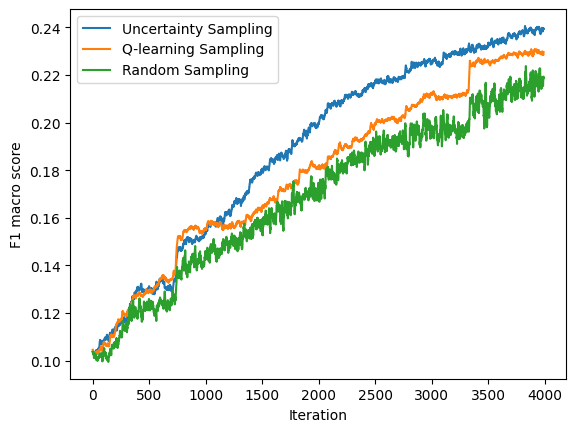

2815
2794
75:State_key(predict_proba=3, hit=0, lof=0, novelty=0, faiss=1) 1 0.002425728946693861 
9:State_key(predict_proba=4, hit=1, lof=0, novelty=0, faiss=0) 1 0.0017646410241567699 
32:State_key(predict_proba=1, hit=0, lof=0, novelty=0, faiss=2) 0 0.0017305131905475662 
68:State_key(predict_proba=1, hit=0, lof=0, novelty=0, faiss=0) 1 0.0016608662264603997 
10:State_key(predict_proba=5, hit=1, lof=0, novelty=0, faiss=0) 0 0.0012710555288416641 
7:State_key(predict_proba=5, hit=0, lof=0, novelty=0, faiss=1) 0 0.0011442250940467585 
33:State_key(predict_proba=0, hit=0, lof=0, novelty=0, faiss=0) 1 0.0010341821210690593 
107:State_key(predict_proba=4, hit=1, lof=0, novelty=0, faiss=1) 1 0.0010195182842512814 
27:State_key(predict_proba=1, hit=1, lof=0, novelty=0, faiss=0) 1 0.0007921924258281339 
11:State_key(predict_proba=2, hit=1, lof=0, novelty=0, faiss=3) 1 0.0007056460246457636 
22:State_key(predict_proba=2, hit=1, lof=0, novelty=0, faiss=0) 0 0.0006772926570664603 
22:State_key(

/var/folders/8f/6dw3knc955311yk7rhd5t4980000gn/T/ipykernel_73432/2957044133.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(q.q_count[(row[0], row[1])], end = ":")


In [238]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

data = {"random": [],
        "uncertainty": [],
        "qlearning": [] }

for i in range(len(vis_arr[0]["random"])):
    data["uncertainty"].append(0)
    data["qlearning"].append(0)
    data["random"].append(0)

    for x in range(len(vis_arr)):
        data["uncertainty"][i] += vis_arr[x]["uncertainty"][i]
        data["qlearning"][i]   += vis_arr[x]["qlearning"][i]
        data["random"][i]      += vis_arr[x]["random"][i]

    data["uncertainty"][i] /= len(vis_arr)
    data["qlearning"][i]   /= len(vis_arr)
    data["random"][i]      /= len(vis_arr)
    
# data = q.vis_values

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

fig, ax = plt.subplots()

def fmt_two_digits(x, pos):
    return int(x * batch)

ax.xaxis.set_major_formatter(ticker.FuncFormatter(fmt_two_digits))

for i in range(len(vis_arr)):
    plt.plot(moving_average(vis_arr[i]["uncertainty"], 10), label="Uncertainty Sampling")
    plt.plot(moving_average(vis_arr[i]["qlearning"], 10), label="Q-learning Sampling")
    plt.plot(moving_average(vis_arr[i]["random"], 10), label="Random Sampling")
    plt.xlabel("Iteration")
    plt.ylabel("F1 macro score")
    plt.legend()
    plt.show()

print(q.u_to_i)
print(q.to_i)

for index, row in q.q_df.sort_values(by=["q_value"], ascending=False).iterrows():
    print(q.q_count[(row[0], row[1])], end = ":")
    for el in row:
        print(str(el), end = " ")
    print()